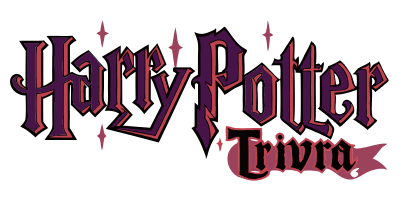

This notebook demonstrates the end-to-end  `question_generation pipeline` run. It uses a 'Demo Limit' of 1 chapter to ensure execution finishes in under 2 minutes.

<div align="center">

## 🪄✨ Try this demo live for yourself here 👉🏼 [![Click here to open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/Harry_Potter_Trivia/blob/main/notebooks/demos/01_pipeline_walkthrough.ipynb) ✨

</div>

[add this link to readme and pipeline notebook for ease of use]

# Notebook introduction

1. purpose of pipeline 
2. design objectives: 
  - Standardize generation -> learn MLOps, also flexibly be able to generate questions (1. fine-tuning of models in future e.g. knowledge distillation)
  - flexbility to generate a variety of high-quality questions
  - (overall schematic of how pipeline fits with other elements: generation > new questions data lake > qa pipeline > data ingestion pipeline)
2. explain use of Prefect
3. give the basic flow (visually with schematic / flow diagram)
4. Explain why emphasis on reporting - focused on being able to trace and reproduce any of the runs. 

built based on experience developed through full prompt engineering cycle (strategy > experimentation > testing > pipeline)
refer to workflow and notebooks.

why was prefect chosen? refer to pipeline notebook for detailed development process and notes

In [ ]:
import os
import sys
from pathlib import Path
import scripts.generate_questions 
import json
from IPython.display import display
from IPython.core.display import JSON, Markdown
from scripts.generate_questions import PIPELINE_ID, generate_questions_pipeline

In [ ]:
# Define what this notebook expects
EXPECTED_PIPELINE_VERSION = "pipe_q_gen_v00"

if PIPELINE_ID != EXPECTED_PIPELINE_VERSION:
    print(f"⚠️ WARNING: This demo was written for {EXPECTED_PIPELINE_VERSION}, "
          f"but the current code is {PIPELINE_ID}. Some features may not match.")
else:
    print(f"✅ Verified: Running demo for {PIPELINE_ID}")

Notebook is run on 

In [ ]:
# ⚠️ SECURITY NOTE:
# This demo requires a valid GEMINI_API_KEY in your 'config.env' file to run.
# The pipeline relies on your local environment and does NOT share keys.

# ☁️ COLAB SETUP (Only runs in the cloud)

try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🚀 Detected Colab Environment. Setting up...")
    
    # 1. Clone the Repo (Lightweight clone)
    if not os.path.exists("Harry_Potter_Trivia"):
        !git clone --depth 1 https://github.com/RSipra/Harry_Potter_Trivia.git
    
    # 2. Move into the directory
    os.chdir("Harry_Potter_Trivia")
    
    # 3. Install the package (Editable mode)
    !pip install -e .
    !pip install prefect google-generativeai python-dotenv
    
    # 4. Handle API Key (Securely)
    # Reviewers can paste their own key, or you can leave it blank to just show code
    import getpass
    os.environ["GEMINI_API_KEY"] = getpass.getpass("Enter Gemini API Key (for live demo): ")
    
    print("✅ Setup Complete! You can now run the pipeline.")

In [ ]:
# Run the pipeline directly (No 'if main' needed here)
generate_questions_pipeline(tasks_to_run=["MCQ_Generation"], chapter_limit=1)

In [ ]:



# Add project root to path (Standard boilerplate)
# ... (your find_project_root logic) ..

## Section 1: The "Flight Plan" (Rendering the Manifest)

In [ ]:


# 1. Find the latest Manifest file
# (You can write a small helper to grab the newest file in logs/manifests/)
manifest_path = ... 

with open(manifest_path, 'r') as f:
    manifest_data = json.load(f)

# 2. Render it as an interactive JSON tree
display(Markdown("### 📋 Step 1: The Flight Plan (Run Manifest)"))
display(JSON(manifest_data))

What this shows: "I treat experiments as immutable records. Here is exactly what I planned to do."

# Section 2: Run pipeline (1 chapter)

using one chapter to save run time.

In [ ]:
!python scripts/generate_questions.py --limit 1

^ The live logs prove the code works

## Section 3: The "Product" (Data Lineage)

- Load the resulting JSONL file into Pandas,
- show: the actual question generated + metadata.
- What this shows: "Look at this batch_generation_info column. I can trace this specific question back to the exact millisecond and model version that created it

In [ ]:
output_file = 
df = pd.read_json(output_file, lines=True)

# Show the "Provenance" - Prove that every row knows its source
display(Markdown("### 📦 Step 2: The Generated Data (With Lineage)"))
display(df[['question', 'answer', 'batch_generation_info']].head(1))

## Section 4: The "Scorecard" (Rendering the Artifact)
- render the exact same Markdown report the script generates in notebook
- shows: "I care about metrics and observability. I don't just run scripts blindly."

In [ ]:
# Load the 'result.json'
display(Markdown(report_md))

For readme
🚀 Quick Start
Want to see the pipeline in action?

▶️ Run the Interactive Demo (Google Colab compatible)

Runs a 1-chapter pilot generation, visualizes the logs, and displays the resulting data lineage.

🔬 Engineering & Research
Interested in the methodology?

🧪 Experimentation Log: Read the deep-dive on how we selected Model Temperature (0.7), engineered the prompts, and validated the SBERT de-duplication strategy against hallucination risks.

🏗️ Architecture Decision Records: Why we chose Prefect over Airflow, and the "Model-per-Task" routing strategy.